# Project Panopticon: Intelligent Exam Proctoring

## Executive Jupyter Notebook

This notebook builds an intelligent time-series classification pipeline for exam proctoring using video telemetry and system event data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    confusion_matrix,
    precision_recall_curve
)

In [5]:
video = pd.read_csv("video_telemetry.csv")
events = pd.read_csv("system_events.csv")

print("Video telemetry shape:", video.shape)
print("System events shape:", events.shape)

Video telemetry shape: (10000, 3)
System events shape: (167, 3)


In [6]:
video.head()

,timestamp,eye_gaze_angle,audio_db
0,2023-12-01 08:00:00,2.560857,36.553781
1,2023-12-01 08:00:01,10.177137,39.102627
2,2023-12-01 08:00:02,5.761714,31.228565
3,2023-12-01 08:00:03,9.787105,34.051405
4,2023-12-01 08:00:04,4.572665,35.245018


In [7]:
events.head()


,timestamp,tab_switches,is_cheating
0,2023-12-01 08:00:32.181296,1,0
1,2023-12-01 08:01:01.923778,1,1
2,2023-12-01 08:01:24.462808,1,0
3,2023-12-01 08:04:10.610743,1,0
4,2023-12-01 08:04:23.902814,1,0


In [8]:
print(video.columns)
print(events.columns)

Index(['timestamp', 'eye_gaze_angle', 'audio_db'], dtype='object')
Index(['timestamp', 'tab_switches', 'is_cheating'], dtype='object')


In [9]:
video["timestamp"] = pd.to_datetime(video["timestamp"])
events["timestamp"] = pd.to_datetime(events["timestamp"])

video = video.sort_values("timestamp")
events = events.sort_values("timestamp")

print("Timestamps converted successfully!")

Timestamps converted successfully!


In [10]:
merged = pd.merge_asof(
    video,
    events,
    on="timestamp",
    direction="nearest"
)

print("Merged dataset shape:", merged.shape)
merged.head()

Merged dataset shape: (10000, 5)


,timestamp,eye_gaze_angle,audio_db,tab_switches,is_cheating
0,2023-12-01 08:00:00,2.560857,36.553781,1,0
1,2023-12-01 08:00:01,10.177137,39.102627,1,0
2,2023-12-01 08:00:02,5.761714,31.228565,1,0
3,2023-12-01 08:00:03,9.787105,34.051405,1,0
4,2023-12-01 08:00:04,4.572665,35.245018,1,0


In [11]:
merged.isnull().sum()


timestamp           0
eye_gaze_angle    732
audio_db          732
tab_switches        0
is_cheating         0
dtype: int64

In [12]:
merged = merged.interpolate(method="linear")
merged = merged.ffill()

merged.isnull().sum()

timestamp         0
eye_gaze_angle    0
audio_db          0
tab_switches      0
is_cheating       0
dtype: int64

In [13]:
merged["gaze_rolling_10s"] = merged["eye_gaze_angle"].rolling(window=10, min_periods=1).mean()

merged["audio_rolling_10s"] = merged["audio_db"].rolling(window=10, min_periods=1).mean()

merged[["eye_gaze_angle", "gaze_rolling_10s", "audio_db", "audio_rolling_10s"]].head(15)

,eye_gaze_angle,gaze_rolling_10s,audio_db,audio_rolling_10s
0,2.560857,2.560857,36.553781,36.553781
1,10.177137,6.368997,39.102627,37.828204
2,5.761714,6.166569,31.228565,35.628325
3,9.787105,7.071703,34.051405,35.234095
4,4.572665,6.571896,35.245018,35.236279
5,7.471741,6.721870,43.685711,36.644518
6,7.148505,6.782818,32.754163,36.088753
7,9.192380,7.084013,43.786308,37.050947
8,4.223888,6.766221,34.097144,36.722747
9,3.524030,6.442002,39.177137,36.968186


In [14]:

X = merged[["eye_gaze_angle", "audio_db", "tab_switches", "gaze_rolling_10s", "audio_rolling_10s"]]

y = merged["is_cheating"]

print(X.head())
print(y.head())

   eye_gaze_angle   audio_db  tab_switches  gaze_rolling_10s  \
0        2.560857  36.553781             1          2.560857   
1       10.177137  39.102627             1          6.368997   
2        5.761714  31.228565             1          6.166569   
3        9.787105  34.051405             1          7.071703   
4        4.572665  35.245018             1          6.571896   

   audio_rolling_10s  
0          36.553781  
1          37.828204  
2          35.628325  
3          35.234095  
4          35.236279  
0    0
1    0
2    0
3    0
4    0
Name: is_cheating, dtype: int64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (8000, 5)
Testing samples: (2000, 5)


In [16]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.02 1.   0.2  1.   0.02 0.07 0.07 0.11 0.11 0.07]


In [18]:
threshold = 0.90
y_pred = (y_prob >= threshold).astype(int)

print(y_pred[:10])

[0 1 0 1 0 0 0 0 0 0]


In [19]:
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.9946091644204852
Recall: 0.5801886792452831


In [20]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1362    2]
 [ 267  369]]


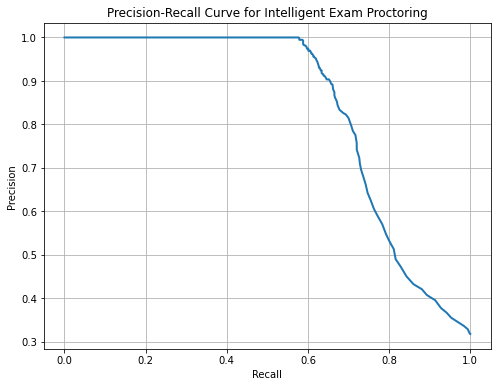

In [21]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(recalls, precisions, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Intelligent Exam Proctoring")
plt.grid(True)
plt.show()

## Executive Conclusion

This project successfully built an intelligent exam proctoring pipeline using asynchronous video telemetry and system event logs.

Key achievements:
- Aligned asynchronous datasets using time-based merging.
- Handled missing telemetry data using interpolation and forward filling.
- Engineered rolling-window features to reduce noise.
- Trained a balanced Random Forest classifier.
- Applied a strict 90% probability threshold to minimize false accusations.
- Evaluated performance using precision, recall, and a precision-recall curve.

The final system prioritizes precision over raw accuracy, ensuring that students are flagged only when the model has high confidence.